In [269]:
import pandas as pd
import numpy as np
import re
import string
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [270]:
df = pd.read_csv("data.csv")

df.head()

,Job Title,Description
0,Data Analyst,job overview were seeking a data analyst to tu...
1,Data Reporting Analyst,about wspc wspc is a cooperative of outstandin...
2,Data Analyst (Power BI/Python),data analyst power bipython employment type fu...
3,Data & Reporting Analyst,our company pharmerica overview the data repor...
4,Data Quality Analyst (Remote Opportunity),vetsez is seeking a data quality analyst teste...


In [271]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (521, 2)

Columns:
['Job Title', 'Description']

Data Types:
Job Title      object
Description    object
dtype: object


In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Job Title    521 non-null    object
 1   Description  521 non-null    object
dtypes: object(2)
memory usage: 8.3+ KB


In [273]:
print(df.isnull().sum())

Job Title      0
Description    0
dtype: int64


In [274]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [275]:
df.describe(include="all")

,Job Title,Description
count,521,521
unique,358,521
top,Data Analyst,job overview were seeking a data analyst to tu...
freq,83,1


In [276]:
print("Unique Job Titles:", df["Job Title"].nunique())

df["Job Title"].value_counts().head(30)

Unique Job Titles: 358


Job Title
Data Analyst                                83
Business Analyst                            16
Senior Data Analyst                         14
Business Data Analyst                        6
Marketing Data Analyst                       5
Business Intelligence Analyst                4
Data Analyst II                              4
Supply Chain Data Analyst                    4
Research Data Analyst                        4
Data Analyst I                               4
Data Analyst 1                               3
Data Analyst III                             3
Data Management Analyst                      3
Healthcare Data Analyst                      3
Operations Data Analyst                      3
Data & Reporting Analyst                     3
Data Reporting Analyst                       3
Data Operations Analyst                      2
Fraud Data Analyst                           2
Data Integration Analyst                     2
Research Analyst                             2
Dat

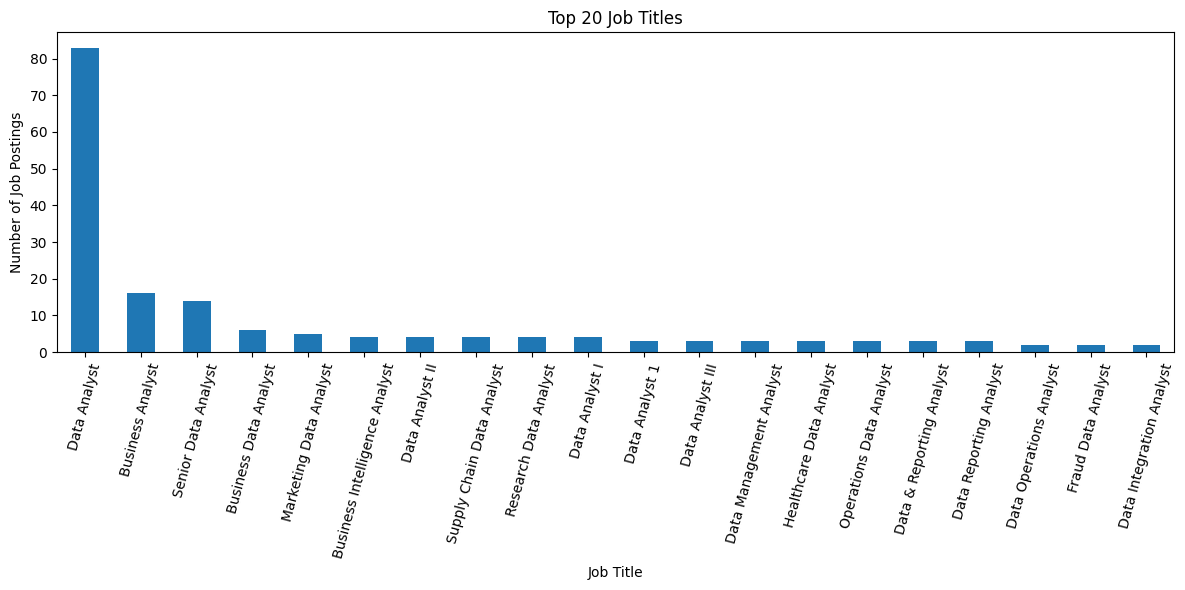

In [277]:
plt.figure(figsize=(12, 6))

df["Job Title"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

***Create Job Categories***


In [278]:
def create_job_category(title):
    title = str(title).lower().strip()

    if "business analyst" in title:
        return "Business Analyst"

    elif (
        "business intelligence" in title
        or "bi analyst" in title
        or "intelligence analyst" in title
    ):
        return "Business Intelligence"

    elif (
        "data scientist" in title
        or "data science" in title
        or "machine learning" in title
        or "ml engineer" in title
        or "artificial intelligence" in title
        or "ai engineer" in title
    ):
        return "Data Science & AI"

    elif "data engineer" in title:
        return "Data Engineering"

    elif any(x in title for x in [
        "marketing data analyst",
        "data marketing analyst",
        "marketing analytics",
        "marketing analyst",
        "digital marketing analyst",
        "sales & marketing data analyst",
        "growth data analyst",
        "brand analytics analyst",
        "demand generation"
    ]):
        return "Marketing Analyst"

    elif any(x in title for x in [
        "financial analyst",
        "financial data analyst",
        "finance data analyst",
        "investment data analyst",
        "financial risk data analyst",
        "finance business analyst",
        "finance & analytics",
        "financial management analyst",
        "fp&a"
    ]):
        return "Finance Analyst"

    elif any(x in title for x in [
        "supply chain data analyst",
        "supply chain analyst",
        "logistics data analyst",
        "supply planning analyst",
        "operations data analyst",
        "operations analyst"
    ]):
        return "Operations Analyst"

    elif any(x in title for x in [
        "research data analyst",
        "research analyst",
        "clinical data analyst",
        "healthcare data analyst",
        "health data analyst",
        "health informatics analyst",
        "clinical informatics analyst",
        "nursing data analyst",
        "bioinformatician"
    ]):
        return "Research & Healthcare Analyst"

    elif any(x in title for x in [
        "it business analyst",
        "it health data analyst",
        "systems analyst",
        "technology analyst",
        "digital & it senior analyst",
        "data and information technology analyst",
        "cloud data analyst",
        "erp data analyst",
        "sap functional"
    ]):
        return "IT & Systems Analyst"

    elif any(x in title for x in [
        "data analyst",
        "reporting analyst",
        "data quality analyst",
        "data integration analyst",
        "data governance analyst",
        "data management analyst",
        "data operations analyst",
        "data insights analyst",
        "data intelligence analyst",
        "data visualization analyst",
        "data products analyst",
        "data solutions analyst",
        "data specialist",
        "analytics analyst"
    ]):
        return "Data Analyst"

    else:
        return "Other"

In [279]:
df["Job_Category"] = df["Job Title"].apply(
    create_job_category
)

df[[
    "Job Title",
    "Job_Category"
]].head(30)

,Job Title,Job_Category
0,Data Analyst,Data Analyst
1,Data Reporting Analyst,Data Analyst
2,Data Analyst (Power BI/Python),Data Analyst
3,Data & Reporting Analyst,Data Analyst
4,Data Quality Analyst (Remote Opportunity),Data Analyst
5,Data Analyst,Data Analyst
6,"Data Reporting Analyst- (***YORK, PA***)",Data Analyst
7,Product Data Analyst,Data Analyst
8,Technical Data Analyst,Data Analyst
9,Data Integration Analyst,Data Analyst


In [280]:
category_counts = df["Job_Category"].value_counts()

print(category_counts)

Job_Category
Data Analyst                     283
Other                             74
Business Analyst                  65
Research & Healthcare Analyst     29
Business Intelligence             17
Operations Analyst                14
Marketing Analyst                 14
IT & Systems Analyst               9
Finance Analyst                    8
Data Science & AI                  6
Data Engineering                   2
Name: count, dtype: int64


In [281]:
category_percentages = (
    df["Job_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentages)

Job_Category
Data Analyst                     54.32
Other                            14.20
Business Analyst                 12.48
Research & Healthcare Analyst     5.57
Business Intelligence             3.26
Operations Analyst                2.69
Marketing Analyst                 2.69
IT & Systems Analyst              1.73
Finance Analyst                   1.54
Data Science & AI                 1.15
Data Engineering                  0.38
Name: proportion, dtype: float64


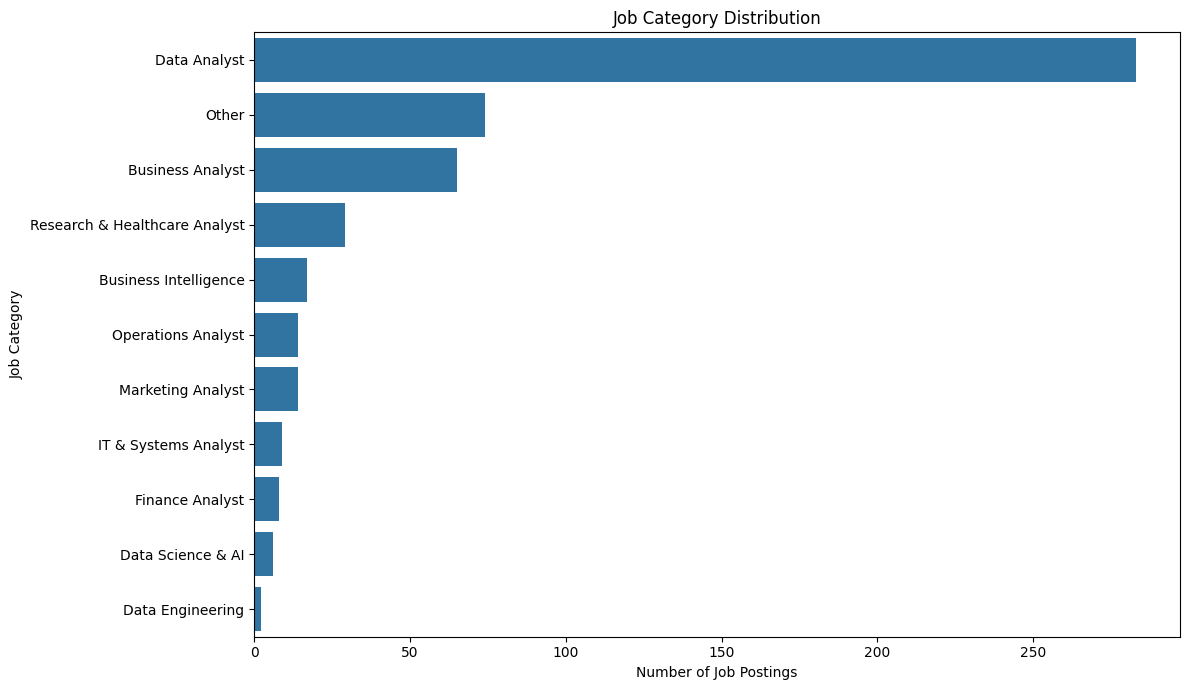

In [282]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="Job_Category",
    order=df["Job_Category"].value_counts().index
)

plt.title("Job Category Distribution")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()

In [283]:
other_titles = df[
    df["Job_Category"] == "Other"
]["Job Title"].value_counts()

print(other_titles.to_string())

Job Title
Sr. Analyst, Analytics & Data Products                                           1
ISRM Data & Analytics GEM Fellow 2025                                            1
MANAGEMENT ANALYST - DATA SOLUTIONS (UNCLASSIFIED)                               1
Analyst, Data Activation                                                         1
Sr Analyst Data                                                                  1
Associate, Data Analytics                                                        1
Senior Analyst, Data Platforming Engineering                                     1
Analyst, Data Operations - Liquidity                                             1
Data Collection Analyst & Panel Coordinator (Research Assistant)                 1
2026 Hotel Operations Rotational Program Analyst | January 2026 Start Date       1
Enterprise Fraud Data Strategy Analyst                                           1
Junior Administrative Analyst (1820) - Multiple Departments Citywide (C00185)

In [284]:
df["text_length"] = df["Description"].astype(str).apply(len)

df["word_count"] = df["Description"].astype(str).apply(
    lambda x: len(x.split())
)

df[[
    "text_length",
    "word_count"
]].describe()

,text_length,word_count
count,521.000000,521.000000
mean,4601.111324,650.433781
std,2114.898566,301.906175
min,2.000000,1.000000
25%,3131.000000,435.000000
50%,4577.000000,638.000000
75%,5830.000000,835.000000
max,14638.000000,2146.000000


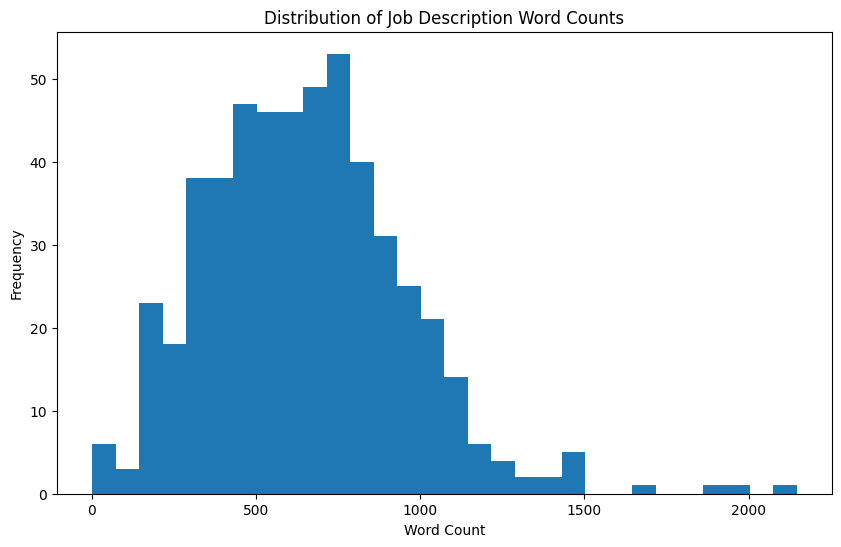

In [285]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["word_count"],
    bins=30
)

plt.title("Distribution of Job Description Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

In [286]:
import nltk
import os

nltk_data_path = os.path.join(
    os.path.expanduser("~"),
    "nltk_data"
)

os.makedirs(
    nltk_data_path,
    exist_ok=True
)

if nltk_data_path not in nltk.data.path:
    nltk.data.path.append(nltk_data_path)

nltk.download(
    "stopwords",
    download_dir=nltk_data_path
)

nltk.download(
    "wordnet",
    download_dir=nltk_data_path
)

nltk.download(
    "omw-1.4",
    download_dir=nltk_data_path

)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

print("NLTK resources ready.")

NLTK resources ready.


[nltk_data] Error loading stopwords: Security Violation
[nltk_data]     [pathsec.urlopen]: refusing a proxied fetch of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be SSRF-safe, opt in via
[nltk_data]     NLTK_ALLOW_PROXIED_URLOPEN=1 or
[nltk_data]     nltk.pathsec.ALLOW_PROXIED_FETCH=True.
[nltk_data] Error loading wordnet: Security Violation
[nltk_data]     [pathsec.urlopen]: refusing a proxied fetch of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be

**Text Preprocessing**

In [287]:
def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Create Clean Text

In [288]:
df["clean_description"] = df[
    "Description"
].apply(preprocess_text)

df[[
    "Description",
    "clean_description"
]].head()

,Description,clean_description
0,job overview were seeking a data analyst to tu...,job overview seeking data analyst turn report ...
1,about wspc wspc is a cooperative of outstandin...,wspc wspc cooperative outstanding independent ...
2,data analyst power bipython employment type fu...,data analyst power bipython employment type fu...
3,our company pharmerica overview the data repor...,company pharmerica overview data reporting ana...
4,vetsez is seeking a data quality analyst teste...,vetsez seeking data quality analyst tester joi...


In [289]:
for i in range(5):
    print("ORIGINAL:")
    print(df.loc[i, "Description"][:500])

    print("\nPROCESSED:")
    print(df.loc[i, "clean_description"][:500])

    print("\n" + "=" * 100 + "\n")

ORIGINAL:
job overview were seeking a data analyst to turn reports from dispatch, safety, accounting, and maintenance into actionable insights and visual dashboards. youll help drive smarter decisions across our trucking operations by translating data into strategies that improve efficiency and performance. key responsibilities analyze data across departments to uncover trends and recommend improvements build and maintain dashboards to track kpis cost per mile, fuel efficiency, driver performance, etc. co

PROCESSED:
job overview seeking data analyst turn report dispatch safety accounting maintenance actionable insight visual dashboard youll help drive smarter decision across trucking operation translating data strategy improve efficiency performance key responsibility analyze data across department uncover trend recommend improvement build maintain dashboard track kpis cost per mile fuel efficiency driver performance etc collaborate team lead identify reporting need deliver insight co

In [290]:
all_words = " ".join(
    df["clean_description"]
).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

common_words

[('data', 6283),
 ('experience', 2520),
 ('business', 2111),
 ('work', 1831),
 ('team', 1654),
 ('analysis', 1482),
 ('skill', 1469),
 ('ability', 1160),
 ('support', 1146),
 ('process', 1040),
 ('analyst', 1010),
 ('management', 980),
 ('year', 930),
 ('job', 911),
 ('position', 905),
 ('opportunity', 903),
 ('report', 902),
 ('system', 890),
 ('employee', 888),
 ('information', 883)]

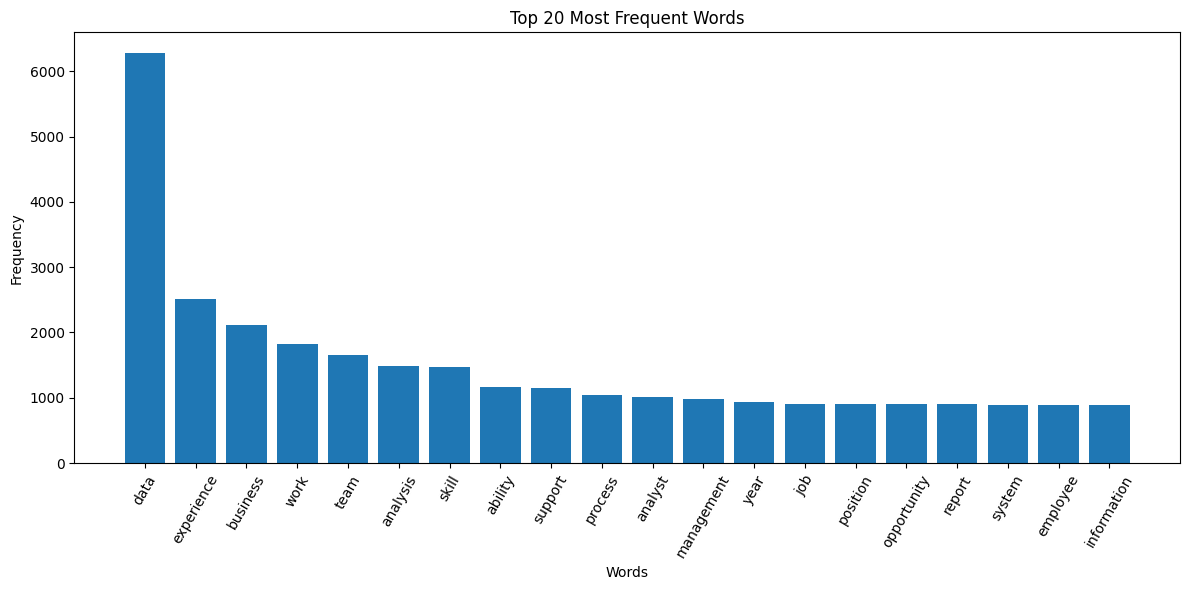

In [291]:
words = [
    x[0] for x in common_words
]

counts = [
    x[1] for x in common_words
]

plt.figure(figsize=(12, 6))

plt.bar(
    words,
    counts
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [292]:
print(
    df["Job_Category"].value_counts()
)

Job_Category
Data Analyst                     283
Other                             74
Business Analyst                  65
Research & Healthcare Analyst     29
Business Intelligence             17
Operations Analyst                14
Marketing Analyst                 14
IT & Systems Analyst               9
Finance Analyst                    8
Data Science & AI                  6
Data Engineering                   2
Name: count, dtype: int64


**Handle Extremely Small Classes**

In [293]:
category_counts = df[
    "Job_Category"
].value_counts()

rare_categories = category_counts[
    category_counts < 5
].index

df["Job_Category"] = df[
    "Job_Category"
].apply(
    lambda x: "Other"
    if x in rare_categories
    else x
)

print(
    df["Job_Category"].value_counts()
)

Job_Category
Data Analyst                     283
Other                             76
Business Analyst                  65
Research & Healthcare Analyst     29
Business Intelligence             17
Operations Analyst                14
Marketing Analyst                 14
IT & Systems Analyst               9
Finance Analyst                    8
Data Science & AI                  6
Name: count, dtype: int64


**Encode Labels**

In [294]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["Job_Category"]
)

print("Classes:")

for i, category in enumerate(
    label_encoder.classes_
):
    print(i, "=", category)

Classes:
0 = Business Analyst
1 = Business Intelligence
2 = Data Analyst
3 = Data Science & AI
4 = Finance Analyst
5 = IT & Systems Analyst
6 = Marketing Analyst
7 = Operations Analyst
8 = Other
9 = Research & Healthcare Analyst


In [295]:
X = df["clean_description"]

y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (521,)
y shape: (521,)


In [296]:
label_counts = pd.Series(y).value_counts()

print(label_counts)

print(
    "\nMinimum class size:",
    label_counts.min()
)

label
2    283
8     76
0     65
9     29
1     17
7     14
6     14
5      9
4      8
3      6
Name: count, dtype: int64

Minimum class size: 6


**Train/Test Split**

In [297]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 416
Testing samples: 105


In [298]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Training TF-IDF shape: (416, 5000)
Testing TF-IDF shape: (105, 5000)


**Naive Bayes**

In [299]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        nb_pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

             Business Analyst       0.00      0.00      0.00        13
        Business Intelligence       0.00      0.00      0.00         3
                 Data Analyst       0.54      1.00      0.70        57
            Data Science & AI       0.00      0.00      0.00         1
              Finance Analyst       0.00      0.00      0.00         2
         IT & Systems Analyst       0.00      0.00      0.00         2
            Marketing Analyst       0.00      0.00      0.00         3
           Operations Analyst       0.00      0.00      0.00         3
                        Other       0.00      0.00      0.00        15
Research & Healthcare Analyst       0.00      0.00      0.00         6

                     accuracy                           0.54       105
                    macro avg       0.05      0.10      0.07       105
                 weighted avg       0.29      0.54      0.38       105



**Logistic Regression**

In [300]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        lr_pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

             Business Analyst       0.58      0.85      0.69        13
        Business Intelligence       0.00      0.00      0.00         3
                 Data Analyst       0.77      0.58      0.66        57
            Data Science & AI       0.00      0.00      0.00         1
              Finance Analyst       0.00      0.00      0.00         2
         IT & Systems Analyst       0.00      0.00      0.00         2
            Marketing Analyst       1.00      0.33      0.50         3
           Operations Analyst       0.00      0.00      0.00         3
                        Other       0.30      0.47      0.37        15
Research & Healthcare Analyst       0.33      0.83      0.48         6

                     accuracy                           0.54       105
                    macro avg       0.30      0.31      0.27       105
                 weighted avg       0.58      0.54      0.54       105



**SVM Model**

In [301]:
svm_model = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        svm_pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

             Business Analyst       0.69      0.69      0.69        13
        Business Intelligence       0.00      0.00      0.00         3
                 Data Analyst       0.64      0.79      0.71        57
            Data Science & AI       0.00      0.00      0.00         1
              Finance Analyst       0.00      0.00      0.00         2
         IT & Systems Analyst       0.00      0.00      0.00         2
            Marketing Analyst       0.00      0.00      0.00         3
           Operations Analyst       0.00      0.00      0.00         3
                        Other       0.24      0.27      0.25        15
Research & Healthcare Analyst       0.00      0.00      0.00         6

                     accuracy                           0.55       105
                    macro avg       0.16      0.17      0.17       105
                 weighted avg       0.47      0.55      0.51       105



**Random Forest**

In [302]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                               precision    recall  f1-score   support

             Business Analyst       1.00      0.23      0.38        13
        Business Intelligence       0.00      0.00      0.00         3
                 Data Analyst       0.56      1.00      0.72        57
            Data Science & AI       0.00      0.00      0.00         1
              Finance Analyst       0.00      0.00      0.00         2
         IT & Systems Analyst       0.00      0.00      0.00         2
            Marketing Analyst       0.00      0.00      0.00         3
           Operations Analyst       0.00      0.00      0.00         3
                        Other       0.00      0.00      0.00        15
Research & Healthcare Analyst       0.00      0.00      0.00         6

                     accuracy                           0.57       105
                    macro avg       0.16      0.12      0.11       105
                 weighted avg       0.43      0.57      0.44       105



*Compare Models*

In [303]:
models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.542857,0.579388,0.542857,0.537533
2,SVM,0.552381,0.468307,0.552381,0.506130
3,Random Forest,0.571429,0.427171,0.571429,0.435647
0,Naive Bayes,0.542857,0.294694,0.542857,0.382011


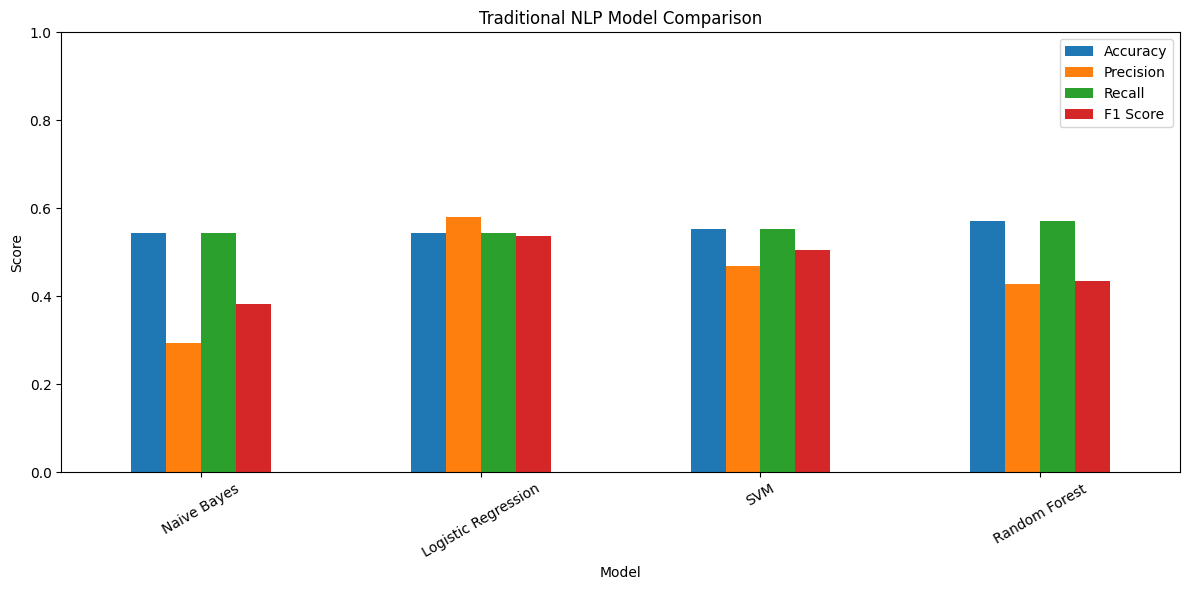

In [304]:
results_df.set_index(
    "Model"
)[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Traditional NLP Model Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

*Select Best Model*

In [305]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print(
    "Best Traditional Model:",
    best_model_name
)

Best Traditional Model: Logistic Regression


***Confusion Matrix***

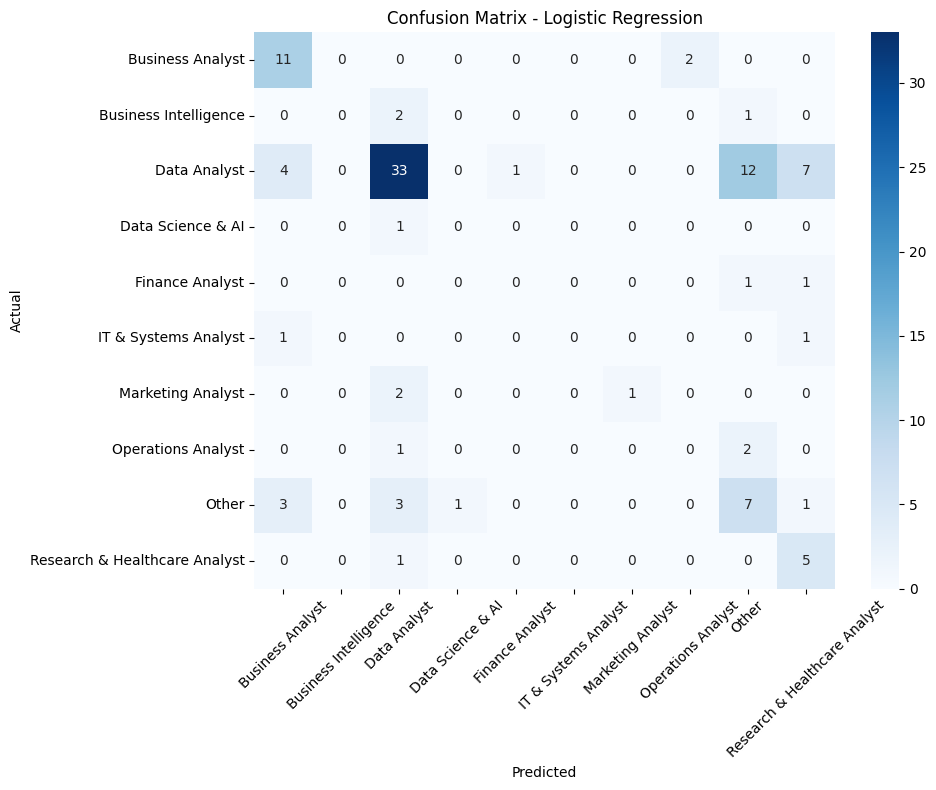

In [306]:
prediction_map = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred
}

best_predictions = prediction_map[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**Transformer Imports**

In [307]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

print("Transformer libraries ready.")

Transformer libraries ready.


**Create Transformer Dataset**

In [308]:
transformer_df = df[
    ["clean_description", "label"]
].dropna().copy()

print(
    transformer_df["label"].value_counts()
)

label
2    283
8     76
0     65
9     29
1     17
7     14
6     14
5      9
4      8
3      6
Name: count, dtype: int64


**Transformer Split**

In [309]:
from sklearn.model_selection import train_test_split

transformer_df = df[
    ["clean_description", "label"]
].dropna().copy()

label_counts = transformer_df["label"].value_counts()

valid_labels = label_counts[
    label_counts >= 10
].index

transformer_df = transformer_df[
    transformer_df["label"].isin(valid_labels)
].copy()

train_df, temp_df = train_test_split(
    transformer_df,
    test_size=0.20,
    random_state=42,
    stratify=transformer_df["label"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(validation_df["label"].value_counts())

print("\nTesting distribution:")
print(test_df["label"].value_counts())

Training: 398
Validation: 50
Testing: 50

Training distribution:
label
2    226
8     61
0     52
9     23
1     14
7     11
6     11
Name: count, dtype: int64

Validation distribution:
label
2    27
8    10
9     5
0     3
1     3
7     1
6     1
Name: count, dtype: int64

Testing distribution:
label
2    30
0    10
8     5
6     2
7     2
9     1
Name: count, dtype: int64


In [310]:
print("Training classes:")
print(train_df["label"].value_counts())

print("\nValidation classes:")
print(validation_df["label"].value_counts())

print("\nTesting classes:")
print(test_df["label"].value_counts())

Training classes:
label
2    226
8     61
0     52
9     23
1     14
7     11
6     11
Name: count, dtype: int64

Validation classes:
label
2    27
8    10
9     5
0     3
1     3
7     1
6     1
Name: count, dtype: int64

Testing classes:
label
2    30
0    10
8     5
6     2
7     2
9     1
Name: count, dtype: int64


In [311]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

validation_dataset = Dataset.from_pandas(
    validation_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

**DistilBERT Tokenizer**

In [312]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

***Tokenization Function***

In [313]:
def tokenize_function(examples):
    return tokenizer(
        examples["clean_description"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

In [314]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

validation_dataset = validation_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/398 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [315]:
train_dataset = train_dataset.remove_columns(
    ["clean_description"]
)

validation_dataset = validation_dataset.remove_columns(
    ["clean_description"]
)

test_dataset = test_dataset.remove_columns(
    ["clean_description"]
)

In [316]:
train_dataset.set_format("torch")

validation_dataset.set_format("torch")

test_dataset.set_format("torch")

**Load DistilBERT**

In [317]:
num_labels = len(
    label_encoder.classes_
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Evaluation Metrics**

In [318]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    }

**Training Arguments**

In [324]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

print("Training arguments created successfully.")

Training arguments created successfully.


**Create Trainer**

In [325]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

In [326]:
trainer.train()

Epoch,Training Loss,Validation Loss


In [ ]:
transformer_results = trainer.evaluate(
    test_dataset
)

print(transformer_results)